# Семинар: Базовый RAG

В рамках ноутбука познакомимся с RAG-системами: их устройством, модификациями, и когда вообще в них возникает необходимость.

In [1]:
!pip install -U datasets==3.6.0 huggingface_hub fsspec

  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached fsspec-2025.3.0-py3-none-any.whl.metadata (11 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached fsspec-2025.3.0-py3-none-any.whl (193 kB)
Using cached dill-0.3.8-py3-none-any.whl (116 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 2.9 MB/s  0:00:00 eta 0:00:01m
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.1.10
    Uninstalling hf-xet-1.1.10:
      Successfully uninstalled hf-xet-1.1.10
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.9.0
    Uninstalling fsspec-2025.9.0:
      Successfully uninstalled fsspec-2025.9.0
  Attempting uninstall: dillm╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [fsspec]
    Found existing installation: dill 0.4.0━━━━━━━━━━━━━━━━━━━ 3/7 [fsspec]
    Uninstalling dill-0.4.0:0m╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [fsspec]
      Successfully uninsta

## 1. Загрузка и подготовка данных

Во-первых, определимся, с какими данными будем иметь сегодня дело.

Будем работать с датасетом на основе телеграм канала, который я ещё заранее спарсила:

In [4]:
! pip install telethon==1.41.2


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [11]:
#@title Введите ваши токены
api_id = "29508696" #@param{type:"string"}
api_id = int(api_id)
api_hash = '53db3202338934b8e1743a17503a37d6' #@param{type:"string"}
session_name = "workshop_preprocessing_v2"

In [12]:
#@title Запуск клиента Telegram
from telethon import TelegramClient, events, sync
from telethon.tl.types import PeerChannel

client = TelegramClient(session_name, api_id, api_hash)

In [13]:
#@title Парсинг данных
async def fetch_messages(channel_username: str, limit: int = 200):
    await client.start()
    entity = await client.get_entity(channel_username)
    msgs = []
    async for msg in client.iter_messages(entity, limit=limit):
        if msg.text is not None and msg.text != '':
            msgs.append({
                'id': msg.id,
                'date': msg.date.isoformat(),
                'text': msg.text,
            })
    await client.disconnect()
    return msgs

channel_name = 'gonzo_ML' #@param{type:"string"}
limit = 2000 #@param{type:"string"}
limit = int(limit)

out = await fetch_messages(channel_name, limit=limit)
print(f'Fetched {len(out)} messages')

Signed in successfully as Sergey Penkovsky; remember to not break the ToS or you will risk an account ban!
Fetched 840 messages


In [14]:
out[1]

{'id': 4193,
 'date': '2025-11-05T17:43:52+00:00',
 'text': 'Сначала рассматривали предобучение в контексте бесконечного компьюта (см. **Pre-training under infinite compute**, https://t.me/gonzo_ML/4038), теперь инференс. И там, и тут, выводы близкие: в любой непонятной ситуации делай ансамблирование 😁\n\nTitle: **Best-of-∞ - Asymptotic Performance of Test-Time Compute**\nAuthors: __Junpei Komiyama, Daisuke Oba, Masafumi Oyamada__\nPaper: https://arxiv.org/abs/2509.21091\nReview: https://arxiviq.substack.com/p/best-of-asymptotic-performance-of\nCode: https://github.com/jkomiyama/BoInf-code-publish\n\nВ статье представлен теоретический фреймворк "Best-of-∞", определяющий асимптотический предел производительности для стратегии best-of-N (BoN) с голосованием по большинству. Чтобы приблизиться к этому пределу с конечными ресурсами, авторы предлагают два ключевых нововведения: 1) Адаптивный алгоритм сэмплинга, который использует байесовское моделирование (в частности, фактор Байеса), чтобы 

In [19]:
# Преобразование в DataFrame
df = pd.DataFrame(out)
df.head()

,id,date,text
0,4195,2025-11-06T18:21:35+00:00,"Классно, когда на Arxiv публикуют sci-fi. \n\n..."
1,4193,2025-11-05T17:43:52+00:00,Сначала рассматривали предобучение в контексте...
2,4191,2025-11-04T22:42:30+00:00,**Всё ещё кипятите?**\n\n**What Really Matters...
3,4190,2025-11-03T19:06:20+00:00,Прекрасная картинка от [a16z](https://a16z.sub...
4,4188,2025-11-03T10:09:25+00:00,Обзор трансформеров с памятью.\n**\nMemory-Aug...


In [21]:
df.to_csv('./content/gonzo_dump.csv')

In [22]:
df = pd.read_csv('./content/gonzo_dump.csv')

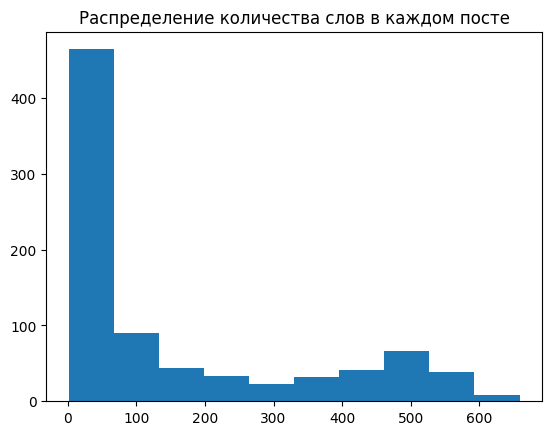

In [23]:
import matplotlib.pyplot as plt

df['word_count'] = df['text'].fillna('').str.split().str.len()

plt.hist(df['word_count'].values)
plt.title("Распределение количества слов в каждом посте");

Попробуем задать вопрос по нашим данным, не используя корректные контексты, в опоре на которые мы могли бы сгенерировать ответы (но не будем).

In [24]:
longest = df[df['word_count'] > 400].sample(5, random_state=42)['text'].values

for i, text in enumerate(longest):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")

Пост номер 1: Вот вам ещё воскресное, про книги.

Прочитал за лето пару книжек про нейтрино и людей вокруг него.

Книга Фрэнка Клоуза более-менее классическая научпоп книга, построенная вокруг истории нескольких людей, в первую очередь Рэя Дэвиса, но также и Ферми, Понтекорво, и не очень многих других. В прошлом году также читал другую книгу Клоуза, про антиматерию, он хорошо пишет, даёт нормальную базу для первого знакомства.

Начинается с открытия радиоактивности, необходимости соблюдения закона сохранения энергии при бета распаде и придумывания Паули новой частицы. Что интересно, в тот момент ещё даже существование нейтрона было не доказано, и Паули по факту придумал и нейтрон, и нейтрино (название пришло уже от Ферми), и не сразу стало ясно, что это разные частицы. Когда стало ясно, Паули считал, что обнаружить нейтрино ("нейтрончик") не удастся.

Лет через пятнадцать Бруно Понтекорво (в последующем сбежавший в Советский Союз, но в конце жизни жалевший об этом) предложил способ как

Теперь подгрузим ещё и данные из, т.н. "золотого набора" -- некоторое количество пар вопрос-контекст, на котором мы будем считать "попадания". В моём случае "контекст" в том числе является и ответом, в вашем же случае ответ может отличаться от контекста в пользу большей естественности (это не так важно)

In [ ]:
test_df = pd.read_excel("golden_mock.xlsx")
test_df.head(5)

,question,text
0,"Почему авторы считают, что попытка сохранить в...",Попытка запихнуть весь контекст в скрытое сост...
1,Как устроен механизм Log-Linear Attention и за...,Токены разбиваются на корзинки с экспоненциаль...
2,Как показал себя Log-Linear Attention по сравн...,На синтетике Log-Linear модификация значительн...
3,В чем заключается основная идея сетей Колмогор...,Авторы предлагают альтернативы классическим мн...
4,Как связаны теоремы Цыбенко и Колмогорова-Арно...,Классические MLP опираются на Универсальную те...


In [ ]:
test_df['question'][1]

'Как устроен механизм Log-Linear Attention и за счет чего он достигает сложности `O(L log L)`?'

In [ ]:
# Log Linear Attention

In [ ]:
test_df['text'][1]

'Токены разбиваются на корзинки с экспоненциально растущим числом токенов. Самые свежие токены обычно важнее для предсказания следующего, потому в одной корзине меньше токенов, и, соответственно, их вес больше, а с отдалением от текущей позиции размер корзинок растет, а вклад индивидуальных токенов убывает. Log-Linear attention сначала вычисляет линейный attention по корзинкам, а затем суммирует с некоторыми обучаемыми коэффициентами результат каждой корзинки (коэффициенты предсказывает отдельная MLP). Число корзинок растет логарифмически с длиной - потому и имеем `O(L log L)` как итоговую сложность операции.'

## 2. Простой RAG

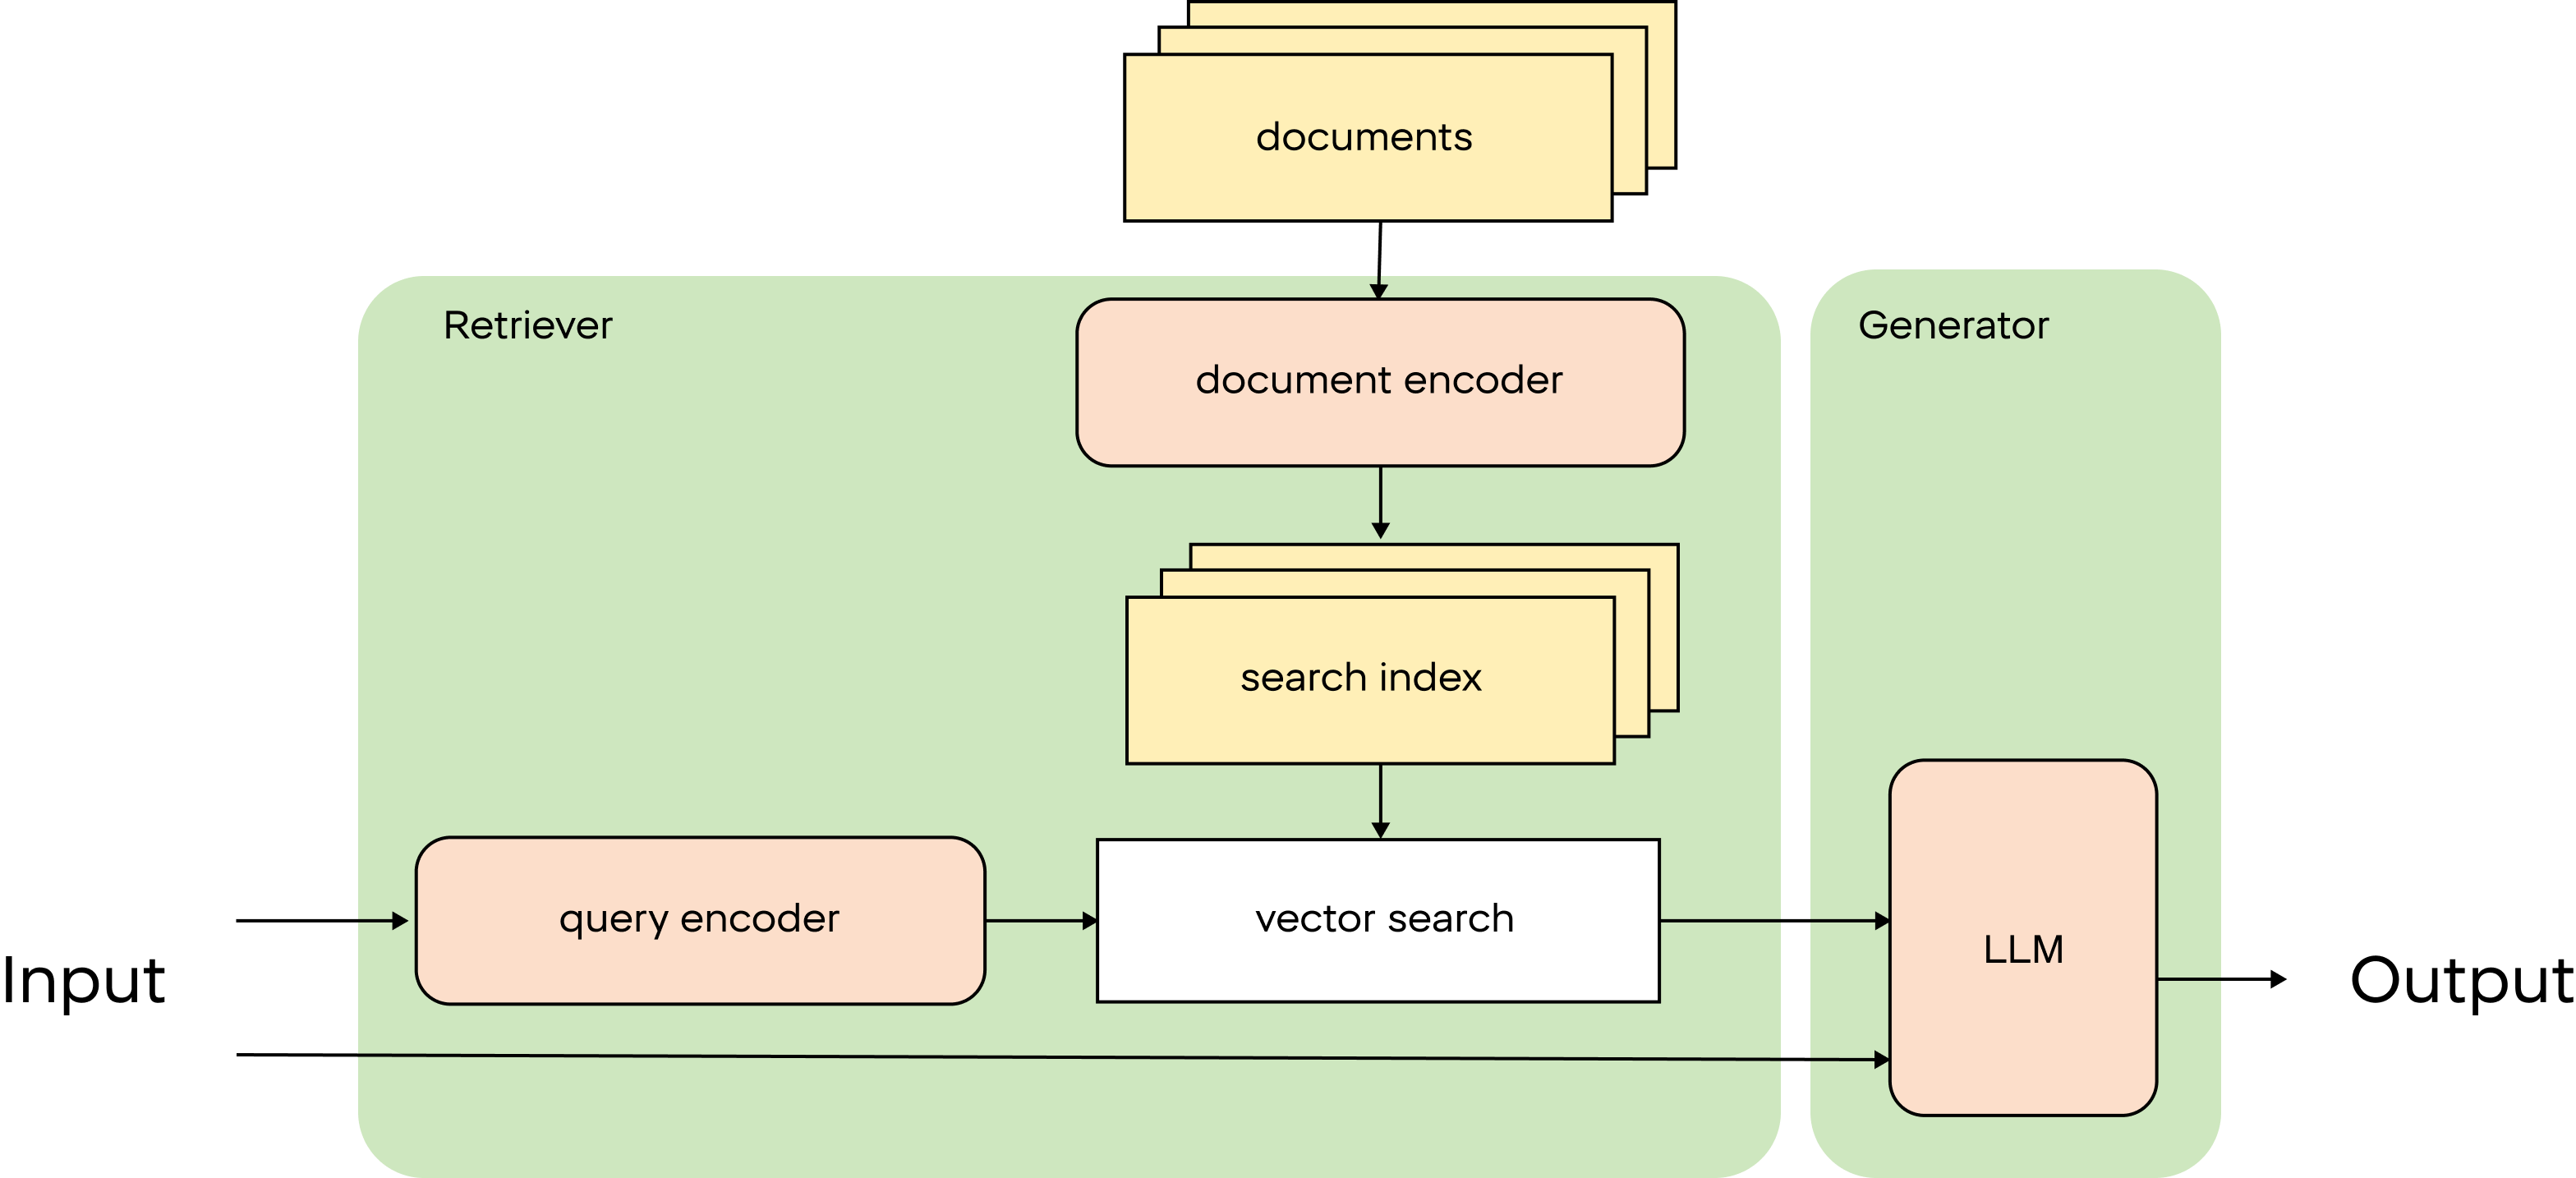

Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks, https://arxiv.org/pdf/2005.11401.pdf

In [ ]:
! pip install qdrant_client

In [ ]:
! pip install langchain_huggingface langchain-qdrant

### 2.1. Определение данных

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import Qdrant
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document

In [ ]:
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['text'],
        metadata={
            "title": row['id']
            }
        )
        for i, row in df.iterrows()
    ])

In [ ]:
# symsearch

"""
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['question'],
        metadata={
            "title": row['id'],
            "text": row['text']
            }
        )
        for i, row in df.iterrows()
    ])

document.metadata['text']
"""

In [ ]:
doc_list[0]

Document(metadata={'title': 4058}, page_content="Что-то интересное:\n\nHappy to release Meta Code World Model (CWM), a 32-billion-parameter dense LLM that enables novel research on improving code generation through agentic reasoning and planning with world models.\nhttps://ai.meta.com/research/publications/cwm\n\nWhen humans plan, we imagine the possible outcomes of different actions. When we reason about code we simulate part of its execution in our head. The current generation of LLMs struggles to do this. What kind of research will an explicitly trained code world model enable? CWM allows us to study this question. Our model is trained on large amounts of coding data & bespoke Python + Bash world modeling data, allowing it to simulate Python function execution and agentic interactions in Bash environments.\n\nThe team and I can’t wait to see what new research will be enabled with a world model. \n📊 Tech Report https://ai.meta.com/research/publications/cwm/ \n⚖️ Models weights https:

In [ ]:
doc_list[0].page_content

"Что-то интересное:\n\nHappy to release Meta Code World Model (CWM), a 32-billion-parameter dense LLM that enables novel research on improving code generation through agentic reasoning and planning with world models.\nhttps://ai.meta.com/research/publications/cwm\n\nWhen humans plan, we imagine the possible outcomes of different actions. When we reason about code we simulate part of its execution in our head. The current generation of LLMs struggles to do this. What kind of research will an explicitly trained code world model enable? CWM allows us to study this question. Our model is trained on large amounts of coding data & bespoke Python + Bash world modeling data, allowing it to simulate Python function execution and agentic interactions in Bash environments.\n\nThe team and I can’t wait to see what new research will be enabled with a world model. \n📊 Tech Report https://ai.meta.com/research/publications/cwm/ \n⚖️ Models weights https://ai.meta.com/resources/models-and-libraries/cwm

In [ ]:
doc_list[0].metadata

{'title': 4058}

### 2.2. Определение эмбеддингов

Как и датасеты есть 2 типа моделей. Симетричные и асиметричные. В данном примере будут рассмотрены 2 типа моделей:

1. `BAAI/bge-m3` - симметричная, тк не надо добавлять промпты или другие параметры для кодирования запроса. Подробнее прочитать [тут](https://huggingface.co/BAAI/bge-m3).
2. `intfloat/multilingual-e5-large` - асиметричная, тк надо добавлять префикс `query: ` и `passage: ` для кодирования запроса и документа соответственно. Документация лежит [тут](https://huggingface.co/intfloat/multilingual-e5-large).

In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


In [ ]:
# symetric model
embed_model_name = "BAAI/bge-m3"
embed_model_kwargs = {'device': device}
embed_encode_kwargs = {'normalize_embeddings': True}
query_encode_kwargs = {}

# asymetric model
"""
embed_model_name = "intfloat/multilingual-e5-large"
embed_model_kwargs = {'device': device}
encode_kwargs = {"prompt": "passage: "} # prompts
query_encode_kwargs = {"prompt": "query: "} # prompts
"""

embeddings = HuggingFaceEmbeddings(
    model_name=embed_model_name,
    model_kwargs=embed_model_kwargs,
    encode_kwargs=embed_encode_kwargs,
    query_encode_kwargs=query_encode_kwargs,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


### 2.3. Определение векторной БД

In [ ]:
qdrant = Qdrant.from_documents(
            doc_list,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

qdrant_retriever = qdrant.as_retriever(verbose=True)

In [ ]:
qdrant_retriever.invoke("Как быть, если в промптах для LLM содержится нерелевантная информация?")

[Document(metadata={'title': 2100, '_id': '2bc5b2ca66e74da1894b94d4a0733b6a', '_collection_name': 'documents'}, page_content='**System 2 Attention (is something you might need too)**\n__Jason Weston, Sainbayar Sukhbaatar__\nСтатья: https://arxiv.org/abs/2311.11829  \n\nВ промптах для LLM часто содержится нерелевантная вопросу информация, отвлекающая модель. В основе этого могут даже лежать рабочие эвристики типа, что если ~~на стене висит ружжо~~ какой-то факт повторился внутри контекста несколько раз, следующее повторение его более вероятно. И это в среднем наверное даже помогает предсказывать следующий токен. Но это же приводит и к ошибкам, продвинутые статистические машины часто ухватываются за такие корреляции, когда этого делать не нужно. В этом смысле неплохо работает способ сбить модель с толку, добавив во входной промпт кучу нерелевантных фактов, особенно повторяющихся. К этому неустойчивы даже самые продвинутые модели.\n\nКак помочь трансформеру не обращать внимание на нерелев

In [ ]:
results = qdrant.similarity_search(
    "Как быть, если в промптах для LLM содержится нерелевантная информация?", k=2
)
results

[Document(metadata={'title': 2100, '_id': '2bc5b2ca66e74da1894b94d4a0733b6a', '_collection_name': 'documents'}, page_content='**System 2 Attention (is something you might need too)**\n__Jason Weston, Sainbayar Sukhbaatar__\nСтатья: https://arxiv.org/abs/2311.11829  \n\nВ промптах для LLM часто содержится нерелевантная вопросу информация, отвлекающая модель. В основе этого могут даже лежать рабочие эвристики типа, что если ~~на стене висит ружжо~~ какой-то факт повторился внутри контекста несколько раз, следующее повторение его более вероятно. И это в среднем наверное даже помогает предсказывать следующий токен. Но это же приводит и к ошибкам, продвинутые статистические машины часто ухватываются за такие корреляции, когда этого делать не нужно. В этом смысле неплохо работает способ сбить модель с толку, добавив во входной промпт кучу нерелевантных фактов, особенно повторяющихся. К этому неустойчивы даже самые продвинутые модели.\n\nКак помочь трансформеру не обращать внимание на нерелев

Теперь поделим всё на чанки (возьмём PD-retriever, так как он показывает себя достаточно хорошо на длинных текстах)

In [ ]:
# ! pip install langchain_community

In [ ]:
! pip install langchain_core==0.3.77

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore

# This text splitter is used to create the parent documents
parent_splitter = RecursiveCharacterTextSplitter()
# This text splitter is used to create the child documents
# It should create documents smaller than the parent
child_splitter = RecursiveCharacterTextSplitter(chunk_size=120, chunk_overlap=0)

store = InMemoryStore()

pd_retriever = ParentDocumentRetriever(
                vectorstore=qdrant,
                docstore=store,
                child_splitter=child_splitter,
                # parent_splitter=parent_splitter,
                verbose=True
            )

In [ ]:
pd_retriever.add_documents(doc_list)

In [ ]:
# PD на коленке
"""
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['text'],
        metadata={
            "title": row['id']
            }
        )
        for i, row in df.iterrows()
    ])
"""
smaller_doc_list = child_splitter.split_documents([
    Document(
        page_content=doc.page_content,
        metadata={
            "title": doc.metadata['title'],
            "bigger_chunk": doc.page_content,
            }
        )
        for doc in doc_list
    ])

In [ ]:
smaller_doc_list[0].page_content

'Что-то интересное:'

In [ ]:
smaller_doc_list[0].metadata['bigger_chunk']

"Что-то интересное:\n\nHappy to release Meta Code World Model (CWM), a 32-billion-parameter dense LLM that enables novel research on improving code generation through agentic reasoning and planning with world models.\nhttps://ai.meta.com/research/publications/cwm\n\nWhen humans plan, we imagine the possible outcomes of different actions. When we reason about code we simulate part of its execution in our head. The current generation of LLMs struggles to do this. What kind of research will an explicitly trained code world model enable? CWM allows us to study this question. Our model is trained on large amounts of coding data & bespoke Python + Bash world modeling data, allowing it to simulate Python function execution and agentic interactions in Bash environments.\n\nThe team and I can’t wait to see what new research will be enabled with a world model. \n📊 Tech Report https://ai.meta.com/research/publications/cwm/ \n⚖️ Models weights https://ai.meta.com/resources/models-and-libraries/cwm

In [ ]:
document.page_content # -- меньший чанк
document.metadata['bigger_chunk'] # -- больший чанк

### 2.4. Проверка ретрива

In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 10]

# Сюда будем записывать результаты
hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = qdrant.similarity_search(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию правильного текста (если есть)
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        if true_text.strip() in txt: # true text ... true text
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 20/20 [00:01<00:00, 10.35it/s]


P@k:
P@1: 0.100
P@3: 0.200
P@5: 0.200
P@10: 0.200

⭐ Mean Reciprocal Rank (MRR): 0.142


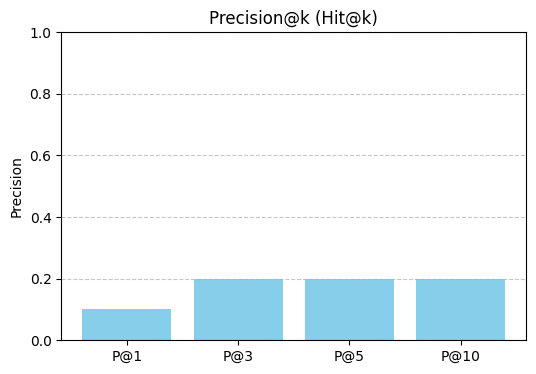

In [ ]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 44.1 MB/s eta 0:00:00


In [ ]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = qdrant.similarity_search(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break
    if rank == 1:
        print(f"question: {question}")
        print(f"context: {retrieved_texts[0]}")

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

 20%|██        | 4/20 [00:00<00:01, 11.32it/s]

question: В чем заключается основная идея сетей Колмогорова-Арнольда (KAN) и чем они отличаются от классических MLP?
context: **KAN: Kolmogorov-Arnold Networks**
__Ziming Liu, Yixuan Wang, Sachin Vaidya, Fabian Ruehle, James Halverson, Marin Soljačić, Thomas Y. Hou, Max Tegmark__
Статья: https://arxiv.org/abs/2404.19756 
Код: https://github.com/KindXiaoming/pykan 
Docs: https://kindxiaoming.github.io/pykan/ 
Twitter: https://x.com/zimingliu11/status/1785483967719981538 

~~Yes, we GAN!~~ Yes, we KAN!

Свежую статью про KAN не расшарил за последние дни только ленивый (я — ленивый). Но обзоров по сути при этом довольно мало. Попробуем.

Авторы предлагают альтернативы классическим многослойным персептронам (MLP) под названием **сети Колмогорова-Арнольда (Kolmogorov-Arnold Networks, KANs)**. Идея в том, что фиксированная для нейрона в MLP функция активации в KAN переезжает в изменяемую часть и становится обучаемой функцией (параметризуется сплайном) вместо веса. Это вроде бы небольшое изме

 40%|████      | 8/20 [00:00<00:01, 10.80it/s]

question: Что такое structured state space duality (SSD) и какую задачу она решает?
context: Авторы подошли к проблеме фундаментально и предложили фреймворк под названием **structured state space duality (SSD)**,


 70%|███████   | 14/20 [00:01<00:00, 10.67it/s]

question: В чем заключается основная идея метода PathFinder и как он отличается от других подходов к многоходовому рассуждению?
context: **PathFinder: Guided Search over Multi-Step Reasoning Paths**
__Olga Golovneva, Sean O'Brien, Ramakanth Pasunuru, Tianlu Wang, Luke Zettlemoyer, Maryam Fazel-Zarandi, Asli Celikyilmaz__
Статья: https://arxiv.org/abs/2312.05180 

Активно развивается тема многоходовых генераций через LLM. Здесь уже были Tree-of-Thought (https://t.me/gonzo_ML/1885), есть Graph-of-Thoughts (https://arxiv.org/abs/2308.09687) и даже Everything-of-Thought (https://arxiv.org/abs/2311.04254) с применением MCTS. Взбудораживший общественность Q* от OpenAI (https://www.technologyreview.com/2023/11/27/1083886/unpacking-the-hype-around-openais-rumored-new-q-model/) предположительно тоже связан с многоходовым планированием в LLM. Если посмотреть глобально, то оно всё ложится в концепцию LLM Programs (https://t.me/gonzo_ML/1584). 

FAIR предложили свой подход к многоходовой генерации

100%|██████████| 20/20 [00:01<00:00, 10.71it/s]

question: В чем заключается основная идея метода MatQuant?
context: **Метод**

MatQuant по постановке ,поверх о**птимизируемых методов квантизации**, с обучаемыми непрерывными или дискретными параметрами.

Основная идея работы в том, что для целочисленных типов данных отстругивая младшие биты от представления с максимальной бытностью, возможно получать приближения разной точности, вложенные друг в друга, как матрешка.

Но если просто огрублять, скажем , int8 квантизацию, работает не очень, поэтому предлагается совместно оптимизировать разные битности одновременно в одном батче с разными весами. 

MatQuant применяют поверх [OmniQuant](https://arxiv.org/abs/2308.13137), в котором оптимизируются скейлы и biasы в квантизации через поблочную дистилляцию, и **QAT**, которая суть просто обучение (с кроссэнтропийным лоссом) с STE через недифференцируемую операцию квантизации.

**Эксперименты**

Метод валидируют преимущественно на Gemma 2 (2b и 9b) моделях и Мистрале 7b. Полагаю, что 🦙 и Квены 

P@k:
P@1: 0.300
P@3: 0.600
P@5: 0.650
P@10: 0.750

⭐ Mean Reciprocal Rank (MRR): 0.464


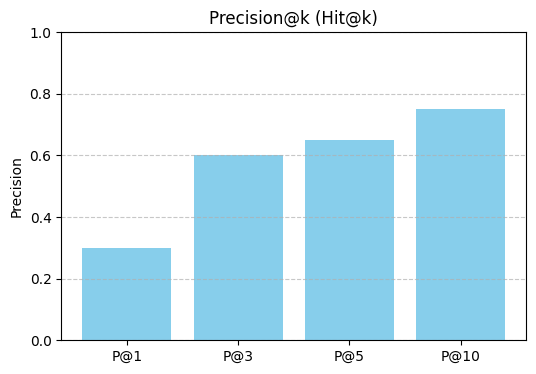

In [ ]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = pd_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 20/20 [00:01<00:00, 10.65it/s]


P@k:
P@1: 0.450
P@3: 0.650
P@5: 0.650
P@10: 0.650

⭐ Mean Reciprocal Rank (MRR): 0.550


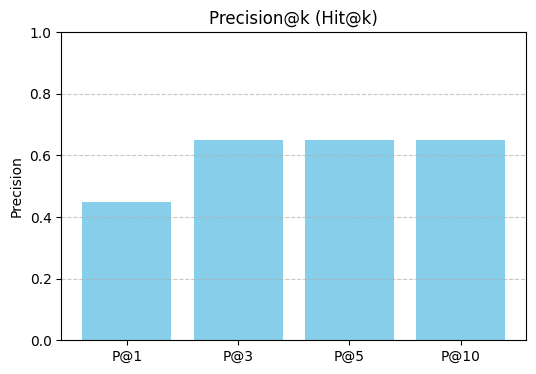

In [ ]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
! pip install rank_bm25

In [ ]:
from langchain_community.retrievers import BM25Retriever
from langchain.retrievers import EnsembleRetriever

bm25_retriever = BM25Retriever.from_documents(doc_list)
bm25_retriever.k = 10

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, qdrant_retriever],
    weights=[0.3, 0.7],  # BM25 + Qdrant
)

In [ ]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = ensemble_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 20/20 [00:02<00:00,  8.43it/s]


P@k:
P@1: 0.450
P@3: 0.600
P@5: 0.600
P@10: 0.600

⭐ Mean Reciprocal Rank (MRR): 0.512


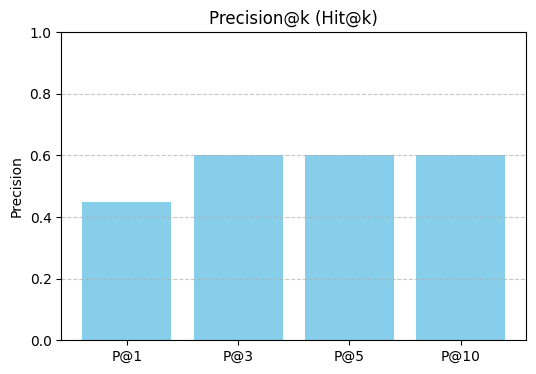

In [ ]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


100%|██████████| 20/20 [00:00<00:00, 40.23it/s]


P@k:
P@1: 0.400
P@3: 0.500
P@5: 0.500
P@10: 0.550

⭐ Mean Reciprocal Rank (MRR): 0.438


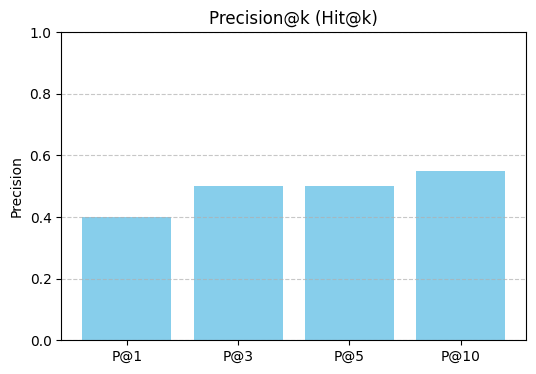

In [ ]:
from rapidfuzz import fuzz

k_values = [1, 3, 5, 10]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = bm25_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(retrieved_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 3. Модификации RAG

### 3.1. Query Expansion

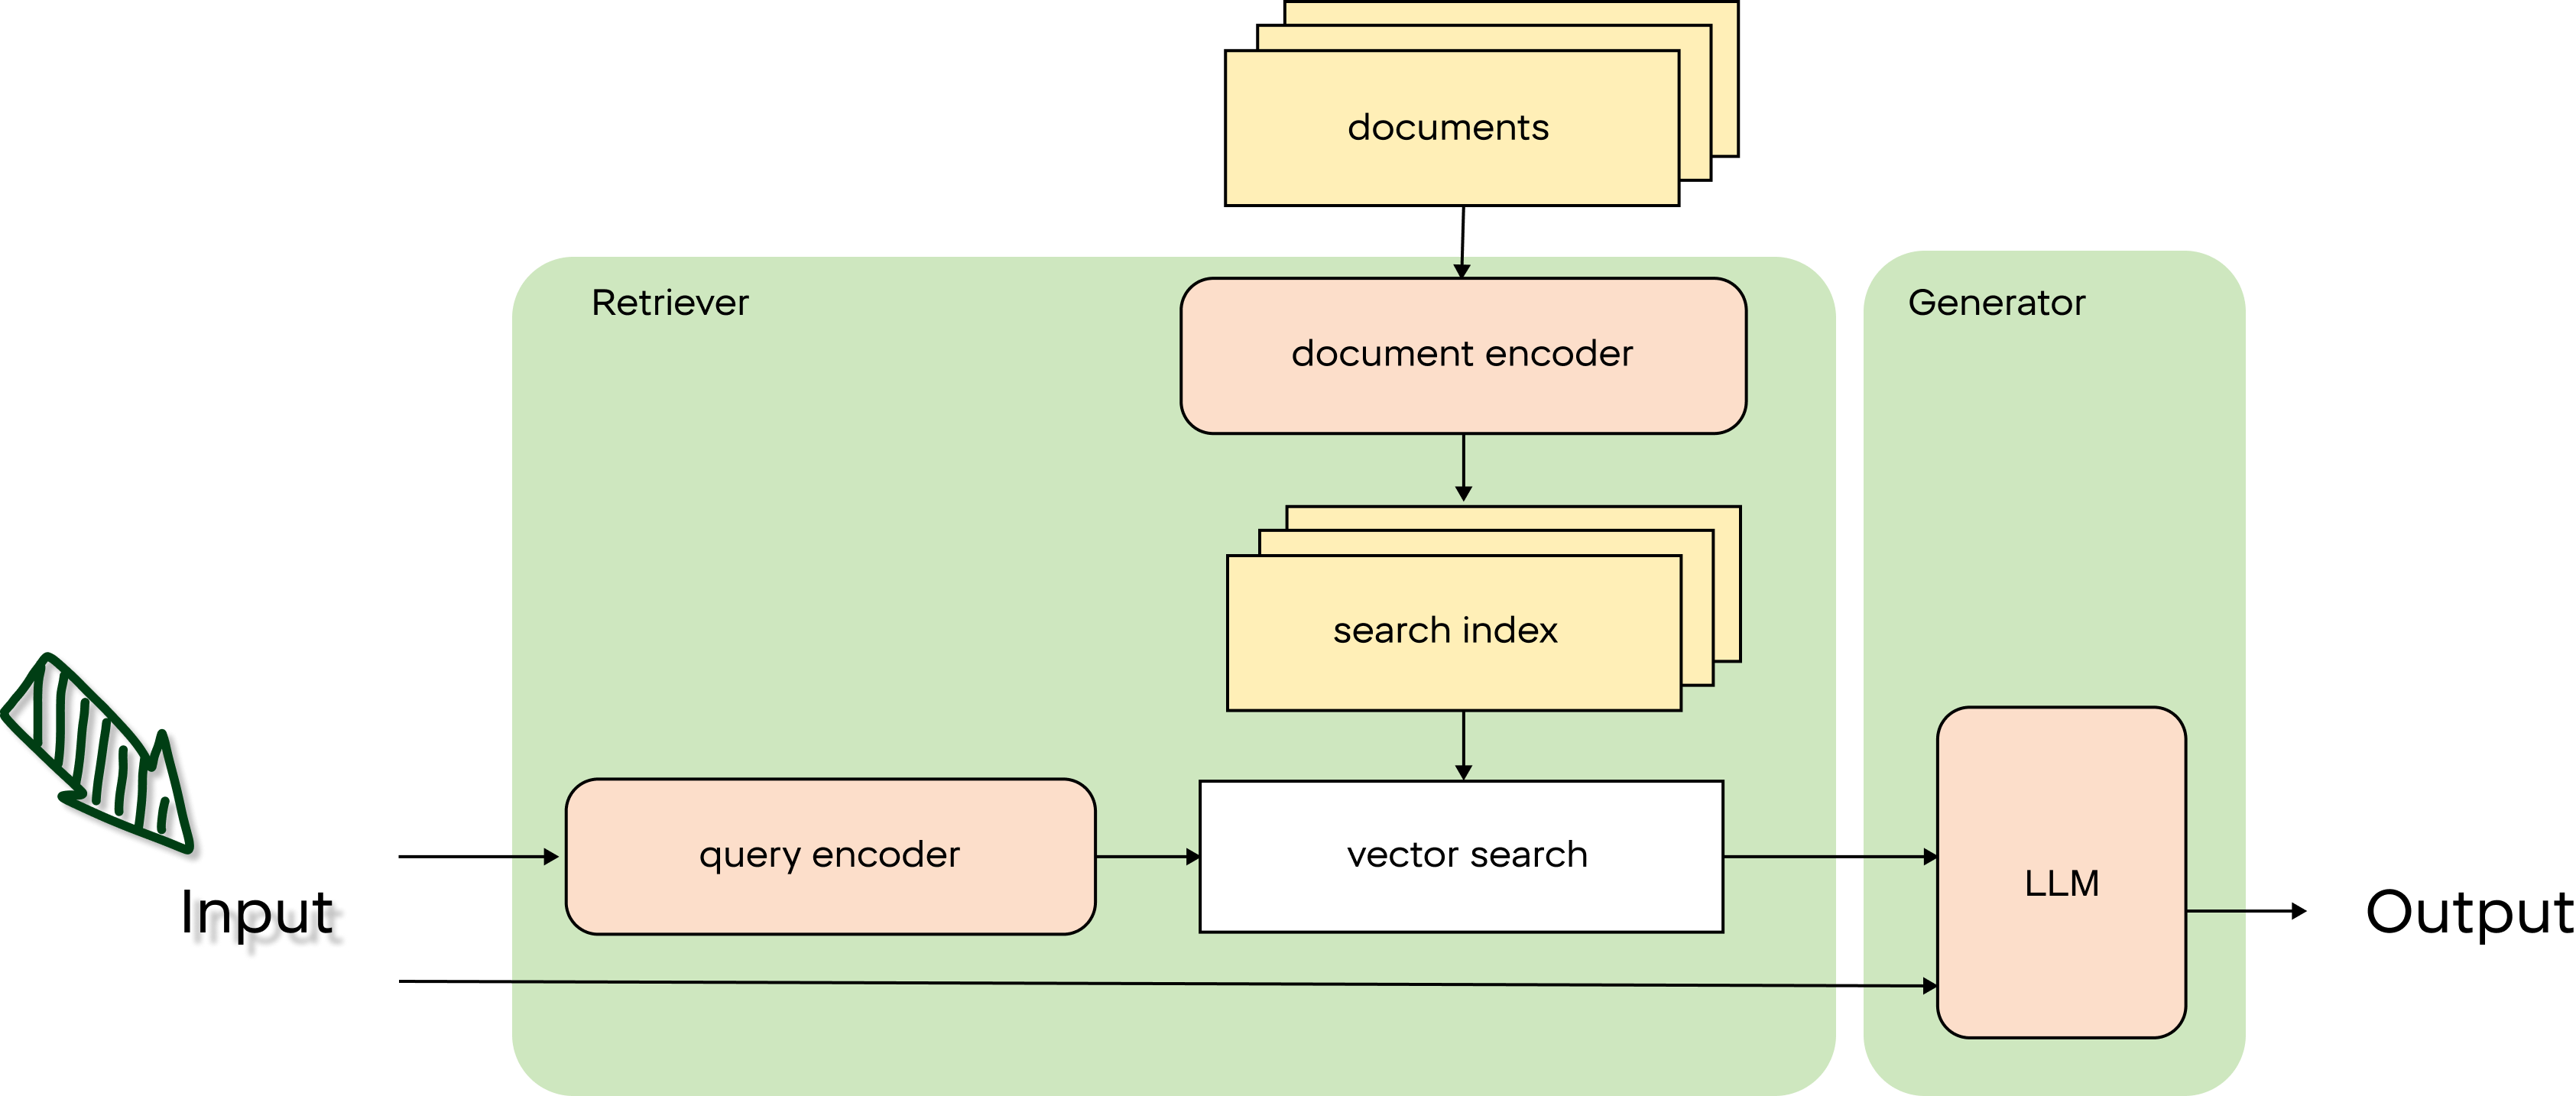

Часто случается так, что пользователи задают вопросы совсем не так, как мы ожидаем: с опечатками, неполно, неграмотно, и с этим нужно уметь работать (потому что у нас нет выбора).

Как правило, проблему с нестандартными, но полными запросами мы решаем перефразированием вопроса пользователя:

In [ ]:
from transformers import pipeline
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

generation_pipeline = pipeline(
    "text-generation",
    model="RefalMachine/ruadapt_qwen2.5_3B_ext_u48_instruct_v4",
    device=device,
    dtype=torch.float16
)

cuda


config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

Device set to use cuda


In [ ]:
original = "чё делать если в промптах нерелевантная инфа?"
messages = [
    {"role": "system", "content": "Ты LLM-инженер и должен перефразировать вопросы пользователя, исправив грамматику, но не меняя смысл."},
    {"role": "user", "content": original},
]

paraphrased = generation_pipeline(messages, max_new_tokens=256, do_sample=True, temperature=0.5, top_p=0.9)[0]['generated_text'][-1]['content']
print(paraphrased)

Что следует предпринять, если в промпте присутствуют несвязные или ненужные данные?


### 3.2. Reranking

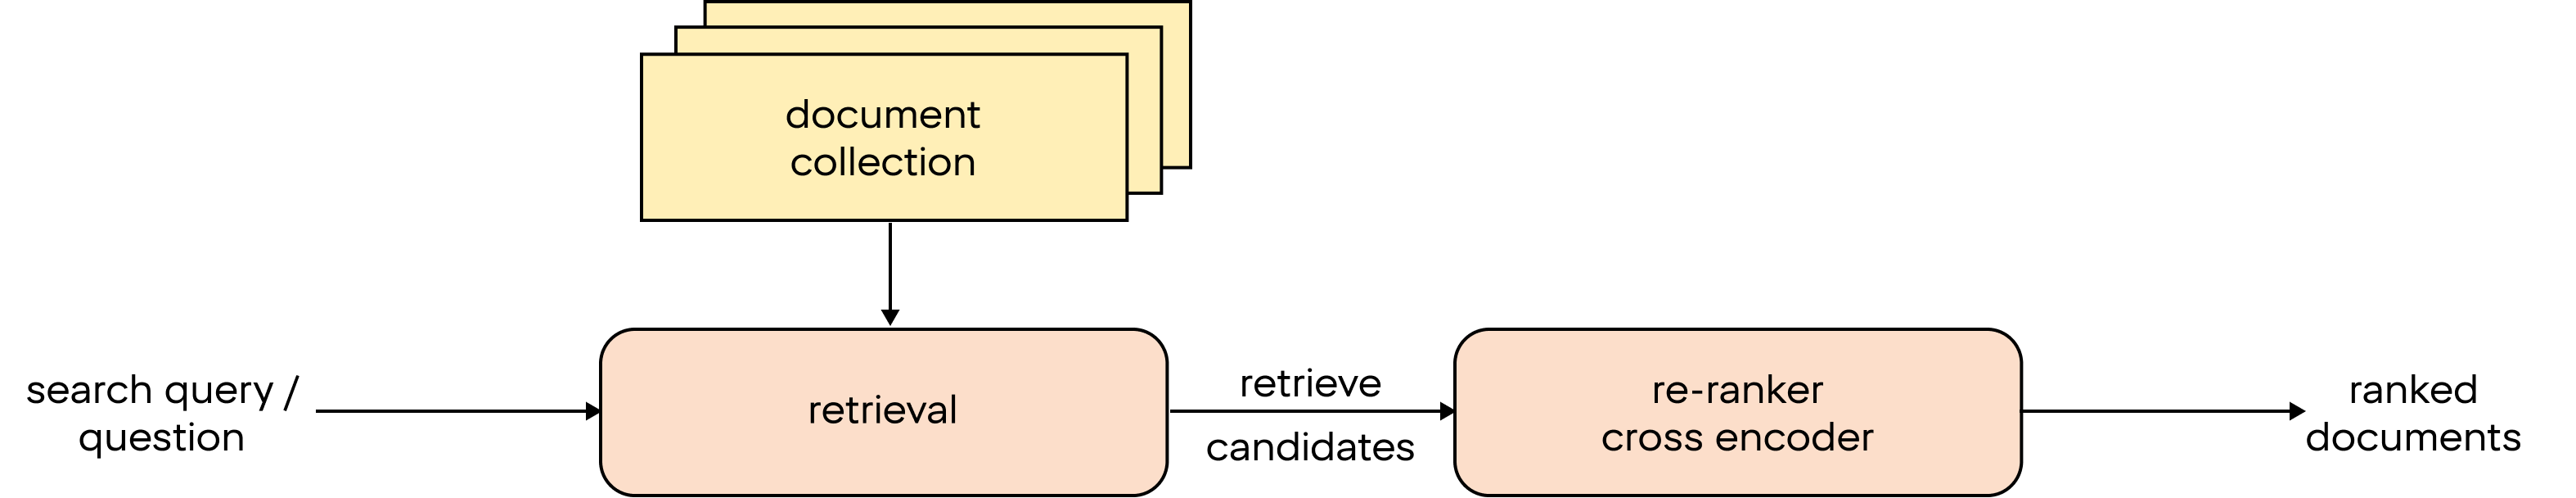

Reranker – это языковая модель, принимающая два текста и возвращающая близость между ними. В качестве реранкера мы будем использовать специальную мультиязычную модель, обученную для этих целей amberoad/bert-multilingual-passage-reranking-msmarco.

In [ ]:
#! pip install langchain_community

In [ ]:
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

In [ ]:
cross_encoder = HuggingFaceCrossEncoder(
    model_name='BAAI/bge-reranker-v2-m3',
    model_kwargs={'device': device}
)
sum([p.numel() for p in cross_encoder.client.model.parameters()])

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

567755777

In [ ]:
import numpy as np

k_values = [1, 3, 5, 10, 20]

hits_at_k = {k: 0 for k in k_values}
reciprocal_ranks = []
threshold = 80  # порог похожести в процентах


for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    question = row["question"]
    true_text = row["text"]

    # Получаем top-k результатов
    results = pd_retriever.invoke(question, k=max(k_values))
    retrieved_texts = [r.page_content for r in results]
    scores = cross_encoder.score([(question, text) for text in retrieved_texts])
    idxs = np.argsort(scores)[::-1][:max(k_values)]

    new_texts = [retrieved_texts[i] for i in idxs]

    # Находим позицию с fuzzy matching
    rank = None
    for i, txt in enumerate(new_texts, start=1):
        similarity = fuzz.partial_ratio(true_text, txt)  # 0–100
        if similarity >= threshold:
            rank = i
            break

    # Reciprocal Rank
    reciprocal_ranks.append(1 / rank if rank else 0)

    # Подсчёт попаданий в топ-k
    for k in k_values:
        if rank and rank <= k:
            hits_at_k[k] += 1

p_at_k = {k: hits_at_k[k] / len(test_df) for k in k_values}
mrr = sum(reciprocal_ranks) / len(reciprocal_ranks)

100%|██████████| 20/20 [00:09<00:00,  2.00it/s]


P@k:
P@1: 0.550
P@3: 0.650
P@5: 0.650
P@10: 0.650
P@20: 0.650

⭐ Mean Reciprocal Rank (MRR): 0.600


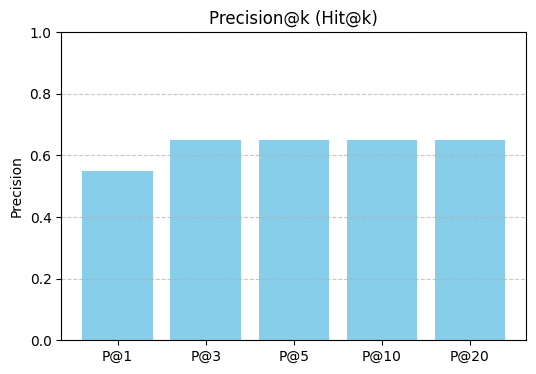

In [ ]:
print("P@k:")
for k, v in p_at_k.items():
    print(f"P@{k}: {v:.3f}")

print(f"\n⭐ Mean Reciprocal Rank (MRR): {mrr:.3f}")

plt.figure(figsize=(6,4))
plt.bar([f"P@{k}" for k in k_values], list(p_at_k.values()), color='skyblue')
plt.title("Precision@k (Hit@k)")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Bonus: LLM-as-a-judge

In [ ]:
import json
import torch
from tqdm import tqdm
from typing import List, Dict, Any
from rapidfuzz import fuzz
from transformers import pipeline

# --- 1. LLM pipeline ---
generation_pipeline = pipeline(
    "text-generation",
    model="RefalMachine/ruadapt_qwen2.5_3B_ext_u48_instruct_v4",
    device=device,
    dtype=torch.float16
)

# --- 2. Pairwise Prompt Builder ---
def build_pairwise_prompt(question: str, candidate: str, gold_text: str = None, threshold: float = 0.6) -> List[Dict[str, str]]:
    """
    Формирует сообщения для chat-like модели.
    Модель должна вернуть JSON со score и is_relevant.
    """
    system = (
        "Ты LLM-судья. Определи, насколько кандидатский текст релевантен вопросу."
        " Ответь ТОЛЬКО JSON в формате: {\"score\": float 0..1, \"is_relevant\": bool}."
    )

    user = f"""
    [Вопрос]
    {question}

    [Кандидат]
    {candidate}
    """

    return [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]

# --- 3. Безопасный парсер JSON ---
def parse_json(s: str) -> Dict[str, Any]:
    try:
        return json.loads(s)
    except Exception:
        start = s.find("{")
        end = s.rfind("}")
        if start != -1 and end != -1 and end > start:
            try:
                return json.loads(s[start:end+1])
            except Exception:
                pass
        return {"score": 0.0, "is_relevant": False}

# --- 4. Pairwise LLM Judge ---
def llm_judge_pairwise(
    question: str,
    candidates: List[str],
    gold_text: str = None,
    threshold: float = 0.6,
    temperature: float = 0.2
):
    """
    Возвращает словарь с оценками каждого кандидата и индексом первого релевантного.
    """
    items = []
    for i, cand in enumerate(candidates, start=1):
        messages = build_pairwise_prompt(question, cand, gold_text, threshold)
        result = generation_pipeline(
            messages,
            max_new_tokens=128,
            do_sample=True,
            temperature=temperature,
            top_p=0.9
        )

        # result[0]['generated_text'] — список сообщений (как у QwenChat)
        raw_text = result[0]['generated_text'][-1]['content']
        data = parse_json(raw_text)
        score = float(data.get("score", 0))
        is_rel = bool(data.get("is_relevant", False))
        items.append({"index": i, "score": score, "is_relevant": is_rel})

    first_rel = next((it["index"] for it in items if it["is_relevant"]), None)
    return {"first_relevant_index": first_rel, "items": items}


####Коэффициент Коэна κ (Cohen’s Kappa)


**Коэффициент Коэна κ** — мера согласия **двух аннотаторов** (или двух «судей») при категоризации объектов, **скорректированная на случайное совпадение**.

* Пусть есть два набора меток для N объектов: (A) и (B).
* (p_o) — наблюдаемая доля совпадений (accuracy).
* (p_e) — ожидаемая доля совпадений «по случаю» (исходя из частот классов у каждого аннотатора).

Тогда:
$$
\kappa ;=; \frac{p_o - p_e}{1 - p_e}.
$$

* Если (\kappa = 1): полное согласие (лучше не бывает).
* Если (\kappa = 0): согласие не лучше случайного.
* Если (\kappa < 0): хуже случайного — систематическое расхождение.

**Интерпретация (популярная шкала Landis & Koch, условная!)**

* **< 0.00** — плохое
* **0.00–0.20** — слабое
* **0.21–0.40** — удовлетворительное
* **0.41–0.60** — умеренное
* **0.61–0.80** — существенное
* **0.81–1.00** — почти идеальное

> Важно: κ чувствителен к **дисбалансу классов** и **смещению порогов**. Если один аннотатор чаще ставит «релевантно», чем другой, κ может снижаться, даже при высокой точности.


#### Другие советы:

* Для LLM-судьи ставьте **temperature=0** и требуйте **строгий JSON** — меньше дрейфа.
* Снижайте стоимость: сначала **retrieval → rerank (cross-encoder)**, и уже **на top-10** зовите LLM-judge.

### Быстрый чек-лист по базовым RAG техникам и их выбору:

1. Есть ли внешние документы, от которых зависит правильность ответа?
    * Да; Объём документов больше контекстного окна модели?
        * Да → нужен RAG, ретривер/чанкирование.
        * Нет → можно попытаться засунуть все документы в системный промпт.
    * Нет; Не используем контексты при генерации
2. Запрос короткий и отличается от формулировок в документах?
    * Да, несильно → подумай о различных энкодерах, query expansion, reranker.
    * Да, сильно → скорее всего стоит использовать симметричный поиск вместо асимметричного
3. Нужно цитирование / трассируемость?
    * Да → делай RAG (с сохранением источников).
4. Домены с высокой ценой ошибки?
    * Да → RAG + строгая инструкция «опираться только на контекст».

А что если пользователи могут задавать оба вида вопросов, и мы хотим уметь отвечать на оба? Да давайте просто всё в RAG засунем...

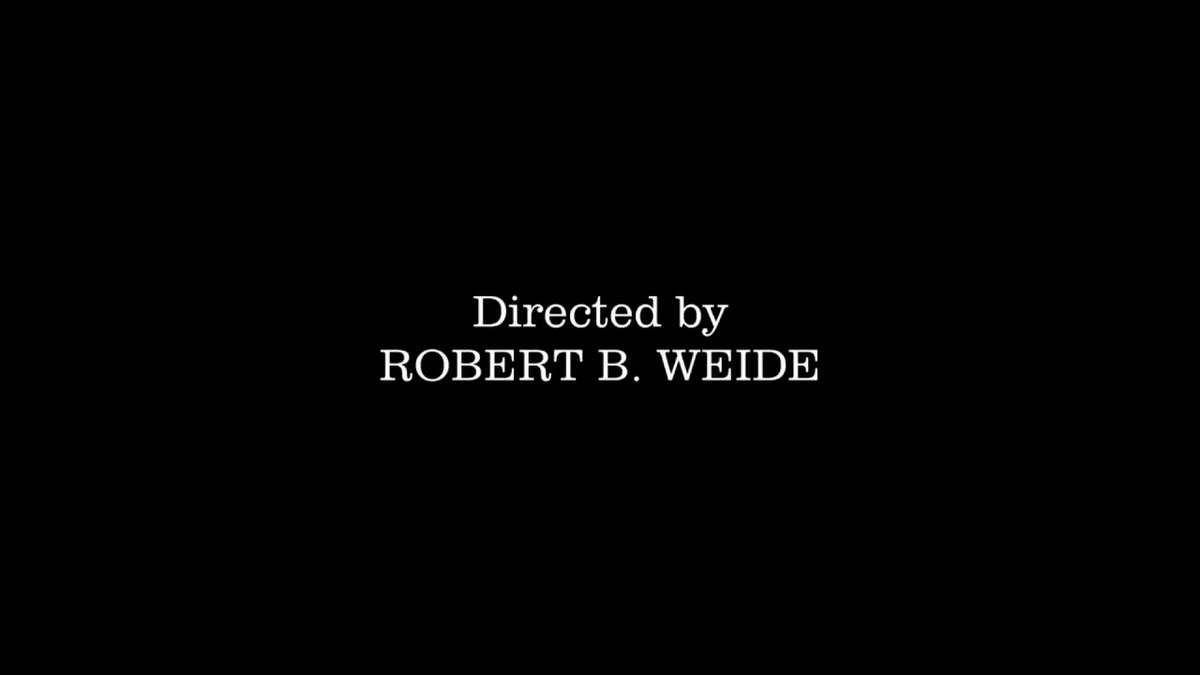

Call me maybe!! tg: @xufana